### Import Dependencies

In [78]:
from google import genai
from google.genai import types
import pandas as pd
import cohere
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.http.models import  VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from typing import Literal, Dict, Annotated, List, Any
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import ToolNode

Single node graph

In [4]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str

In [6]:
def append_vibes_to_query(state:State) -> dict:
    return{
        "answer":f"{state.message} {state.vibe}"
    }

In [9]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")

workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

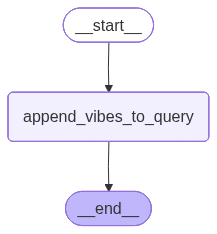

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling sad"
}

In [13]:
result = graph.invoke(initial_state)

In [14]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling sad",
 'vibe': "I'm feeling sad"}

Conditional Graph

In [15]:
class State(BaseModel):
    message: str
    answer: str = ""

In [16]:
def append_vibes_to_query(state:State) -> dict:
    return{
        "answer":state.message
    }

In [17]:
def append_vibe_1(state:State) -> dict:

    vibe = "I'm feeling sad"
    return{
        "answer":f"{state.message} {vibe}"
    }

def append_vibe_2(state:State) -> dict:
    vibe = "I'm feeling happy"
    return{
        "answer":f"{state.message} {vibe}"
    }

def append_vibe_3(state:State) -> dict:
    vibe = "I'm feeling anxious"
    return{
        "answer":f"{state.message} {vibe}"
    }   

In [20]:
def router(state:State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    vibe_path = random.choice(vibes)

    return vibe_path

In [22]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)
graph = workflow.compile()

In [23]:
result = graph.invoke(initial_state)

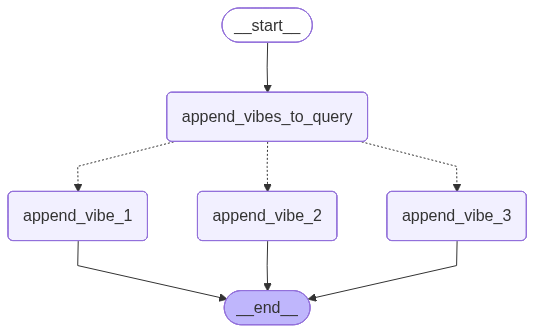

In [24]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {
    "message": "I am here to add some vibes!",
}

In [25]:
result = graph.invoke(initial_state)

In [26]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling sad"}

In [29]:
workflow = StateGraph(State)


workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    START,
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)
graph = workflow.compile()

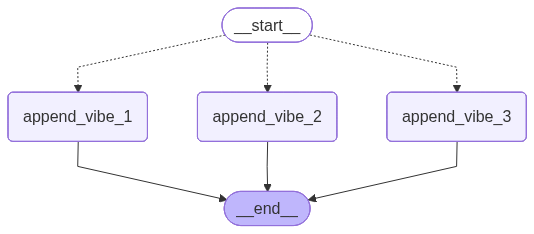

In [30]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Explore Langchain Tool Calling

In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

In [33]:
@tool
def dummy_tool(a: str, b: str) -> str:
    """ Concatenate two strings 
    
    Args:
        a: First string
        b: Second string
        
    Returns:
        Concatenated string
    """

    return f"hello {a} and {b}"

In [36]:
import os
gemini_client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", client=gemini_client)

llm_with_tools = llm.bind_tools([dummy_tool], tool_choice="auto")


In [37]:
response = llm_with_tools.invoke("Use dummy tool to concatenate 'world' and 'hello'")

In [38]:
response

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'dummy_tool', 'arguments': '{"b": "hello", "a": "world"}'}, '__gemini_function_call_thought_signatures__': {'w8WwHnpe': 'EjQKMgERTTIP0ZJRNVJx4nlSWNlmfwlhNWpIzOAIVLjqPMoua7iHTPEmlChl2hGivpYnCODw'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f5d7b-b61f-71e1-806d-0634a8a05551-0', tool_calls=[{'name': 'dummy_tool', 'args': {'b': 'hello', 'a': 'world'}, 'id': 'w8WwHnpe', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 22, 'total_tokens': 114, 'input_token_details': {'cache_read': 0}})

In [39]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'b': 'hello', 'a': 'world'},
  'id': 'w8WwHnpe',
  'type': 'tool_call'}]

### Agent Graph

In [40]:
@tool
def append_vibe(query: str, vibe: str) -> str:
    """ Append a vibe to the query 

    Args:
        query: The query to append the vibe to
        vibe: The vibe to append to the query
        
    Returns:
        The query with the vibe appended
    """

    return f"{query} {vibe}"

In [72]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [79]:
def agent_node(state: State) -> dict:
    prompt_template = """You are an assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query.
    - Add a random vibe to the user query.

    ## User Query
    {{ query }}
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.query)

    llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", client=gemini_client)
    llm_with_tools = llm.bind_tools([append_vibe], tool_choice="auto")

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            HumanMessage(content=state.query),
        ]
    )

    return {
        "messages": [response]
    }


In [74]:
def tool_router(state: State) -> str:
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [80]:
workflow = StateGraph(State)

tools = [append_vibe]

tool_node = ToolNode(tools)

workflow.add_edge(START, "agent_node")
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END,
    }
)

workflow.add_edge("tool_node", END)
graph = workflow.compile()

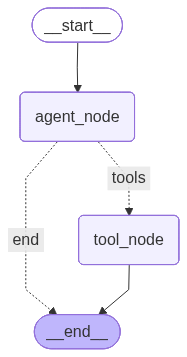

In [55]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [81]:
initial_state = {
    "query": "Give me some vibes!"
}


In [82]:
result = graph.invoke(initial_state)

In [85]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'append_vibe', 'arguments': '{"vibe": "a warm, sun-drenched afternoon in a cozy coffee shop with lo-fi beats playing in the background", "query": "Give me some vibes!"}'}, '__gemini_function_call_thought_signatures__': {'mK44xpmn': 'EjQKMgERTTIPcku3DBeuAyf1A5DyOtlMXpjBFIuQPRXxmdNovbK24QFx9/0icSFoN5nhssfF'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f5da1-368e-7362-a712-3f13453bcc20-0', tool_calls=[{'name': 'append_vibe', 'args': {'vibe': 'a warm, sun-drenched afternoon in a cozy coffee shop with lo-fi beats playing in the background', 'query': 'Give me some vibes!'}, 'id': 'mK44xpmn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 49, 'total_tokens': 214, 'input_token_details': {'cache_read': 0}}),
  ToolMessa

In [87]:
result["messages"]

[AIMessage(content=[], additional_kwargs={'function_call': {'name': 'append_vibe', 'arguments': '{"vibe": "a warm, sun-drenched afternoon in a cozy coffee shop with lo-fi beats playing in the background", "query": "Give me some vibes!"}'}, '__gemini_function_call_thought_signatures__': {'mK44xpmn': 'EjQKMgERTTIPcku3DBeuAyf1A5DyOtlMXpjBFIuQPRXxmdNovbK24QFx9/0icSFoN5nhssfF'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f5da1-368e-7362-a712-3f13453bcc20-0', tool_calls=[{'name': 'append_vibe', 'args': {'vibe': 'a warm, sun-drenched afternoon in a cozy coffee shop with lo-fi beats playing in the background', 'query': 'Give me some vibes!'}, 'id': 'mK44xpmn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 49, 'total_tokens': 214, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content='Give me some vibes! a warm, sun-dre

### Agent Graph with loop back from tools (ReAct)

In [88]:
@tool
def append_vibe(query: str, vibe: str) -> str:
    """ Append a vibe to the query 

    Args:
        query: The query to append the vibe to
        vibe: The vibe to append to the query
        
    Returns:
        The query with the vibe appended
    """

    return f"{query} {vibe}"

In [93]:
class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [107]:
def agent_node(state: State) -> dict:
    prompt_template = """You are an assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query.
    - Add a random vibe to the user query.
    - You must return a tool call in the first interaction.
    """
    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", client=gemini_client)
    llm_with_tools = llm.bind_tools([append_vibe, FinalResponse], tool_choice="auto")

    response = llm_with_tools.invoke(
        [
            HumanMessage(content=prompt),
            *state.messages,
        ]
    )

    final_answer = False
    answer = ""

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")


    return {
        "messages": [response],
        "iteration": state.iteration + 1,
        "final_answer": final_answer,
        "answer": answer
    }


In [108]:
def tool_router(state: State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [109]:
workflow = StateGraph(State)

tools = [append_vibe]

tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")


workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END,
    }
)

workflow.add_edge("tool_node", "agent_node")
graph = workflow.compile()

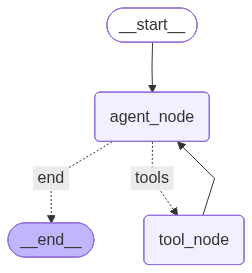

In [110]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [111]:
initial_state = {}

In [112]:
result = graph.invoke(initial_state)

In [113]:
result

{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'append_vibe', 'arguments': '{"query": "What is the weather like?", "vibe": "dreamy and ethereal"}'}, '__gemini_function_call_thought_signatures__': {'c2NWIFW0': 'EjQKMgERTTIPb4rDmIfY6bs3AuEc2E5OaVSgyY1PS0AyTQ++3Uk0GcyvrIucCogac7sZ0b2m'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f5db4-aaa3-7613-b2e3-9263e1c03d44-0', tool_calls=[{'name': 'append_vibe', 'args': {'query': 'What is the weather like?', 'vibe': 'dreamy and ethereal'}, 'id': 'c2NWIFW0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 193, 'output_tokens': 32, 'total_tokens': 225, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='What is the weather like? dreamy and ethereal', name='append_vibe', tool_call_id='c2NWIFW0'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name'